<a href="https://colab.research.google.com/github/bnatsumi/calculo-numerico/blob/main/CN_Atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática I

**Prof. Raquel J. Lobosco — UNIFESP**

**Integrantes:** Bruna Natsumi Ideyama e Lorenzo Faria Girardi

**Divisão de tarefas:**

**Bruna** — C1, C2, D, D1 e D2, E e GIF

**Lorenzo** — A, B, C, D, D1 e D2 e GIF

Este notebook resolve as Partes A a E da atividade: erros de truncamento e
arredondamento, propagação de erros em medidas de pressão arterial e no
escoamento de Hagen–Poiseuille (tubo e nanocateter), e a comparação entre
precisão aritmética (`float32` x `float64`) e validade física do modelo.

## 0. Configuração inicial e funções auxiliares

Deixei tudo que se repete no notebook em um lugar só: as bibliotecas, a paleta
de cores e as funções de truncamento, arredondamento e cálculo de erro. Assim
não corro o risco de usar uma fórmula diferente em cada parte.

### Bibliotecas que usei e para quê

| Biblioteca | Onde usei |
|---|---|
| `numpy` | vetores de valores (raios, medidas de pressão) e os tipos `float32`/`float64` da Parte D.2 |
| `pandas` | montar as tabelas de resultados e formatar os números |
| `matplotlib.pyplot` | todos os gráficos do notebook |
| `matplotlib.gridspec` | **montar o painel único da Parte E** — é ele que me deixa dividir a figura em uma grade e dar tamanhos diferentes para cada quadro |
| `matplotlib.patches` (`FancyBboxPatch`, `Circle`) | as "caixinhas" arredondadas dos textos do painel e os círculos da seção do nanocateter |
| `imageio` | **juntar os quadros e salvar o GIF** (`imageio.mimsave`) |
| `io` (`BytesIO`) | guardar cada quadro do GIF na memória em vez de salvar 41 PNGs no disco |
| `PIL` (Pillow) | só para conferir no final se o PNG do painel bateu o tamanho mínimo pedido (≥ 1600×1000 px) |
| `math` (`trunc`, `pi`) | truncar de verdade (sem arredondar) e o π da equação de Hagen–Poiseuille |
| `IPython.display` | exibir o GIF aqui dentro do notebook |

Ou seja: o **painel da Parte E** é `matplotlib` + `gridspec` + `patches`, e o
**GIF** é `matplotlib` desenhando quadro a quadro + `io` guardando cada quadro
+ `imageio` costurando tudo em um arquivo `.gif`.

In [1]:
# --- Bibliotecas ------------------------------------------------------------
import numpy as np                      # vetores e os tipos float32/float64
import pandas as pd                     # tabelas de resultados
import matplotlib.pyplot as plt         # todos os gráficos
import matplotlib.gridspec as gridspec  # grade do painel único da Parte E
from matplotlib.patches import FancyBboxPatch, Circle  # caixinhas e círculos do painel
import matplotlib.patheffects as pe     # contorno suave no marcador do GIF
from math import trunc, pi              # trunc = corta sem arredondar
import imageio.v2 as imageio            # monta o GIF a partir dos quadros
from PIL import Image                   # só para conferir o tamanho do PNG final
import io                               # guarda cada quadro do GIF na memória

# --- Paleta -----------------------------------------------------------------
# Escolhi uma cor fixa para cada "papel" e usei a mesma em todos os gráficos:
# assim, em qualquer figura, verde escuro = dado original, verde claro =
# arredondado e rosa = truncado. Fica mais fácil de comparar de bater o olho.
COR_ORIGINAL = "#6E7F5E"      # dado original / referência
COR_ARREDONDADO = "#A8C9A0"   # valores arredondados
COR_TRUNCADO = "#D56B7A"      # valores truncados
COR_REF = "#6B4E71"           # textos e linhas de referência
COR_APOIO = "#FFC75F"         # destaques
COR_FUNDO = "#FFF6EE"         # fundo das figuras
COR_NEUTRO = "#E2DED6"        # grades e bordas

# Configuração global do matplotlib: em vez de repetir cor de fundo, cor de
# texto e grade em cada gráfico, defino uma vez aqui e vale para o notebook todo.
plt.rcParams.update({
    "figure.facecolor": COR_FUNDO,
    "axes.facecolor": "#FFFCF8",
    "axes.edgecolor": COR_NEUTRO,
    "axes.grid": True,
    "grid.color": COR_NEUTRO,
    "grid.alpha": 0.7,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": COR_REF,
    "text.color": COR_REF,
    "axes.labelcolor": COR_REF,
    "xtick.color": COR_REF,
    "ytick.color": COR_REF,
    "legend.facecolor": "#FFFCF8",
    "legend.edgecolor": COR_NEUTRO,
})


def estiliza_tabela(df, formato=None):
    """Deixa uma tabela (DataFrame) centralizada e com a cara da paleta.

    O estilo padrão do pandas fica bem desalinhado quando a tabela mistura
    números grandes com notação científica, que é exatamente o nosso caso.
    """
    styler = df.style.hide(axis="index")   # esconde o índice, que não diz nada aqui
    if formato:
        styler = styler.format(formato)    # cada coluna com o seu número de casas
    styler = styler.set_table_styles([
        {"selector": "th", "props": [
            ("background-color", COR_ORIGINAL), ("color", "white"),
            ("text-align", "center"), ("padding", "7px 12px"),
            ("font-weight", "600"), ("border", "none"),
        ]},
        {"selector": "td", "props": [
            ("text-align", "center"), ("padding", "6px 12px"),
            ("border-bottom", f"1px solid {COR_NEUTRO}"),
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"), ("margin", "12px auto"),
            ("background-color", "#FFFCF8"),
        ]},
    ]).set_properties(**{"background-color": "#FFFCF8"})
    return styler


# --- Funções de erro --------------------------------------------------------
# Escrevi as quatro definições que a professora passou em aula, para usar
# sempre as mesmas fórmulas em todas as partes.

def truncar(x, n):
    """Trunca x para n casas decimais, ou seja, corta o resto sem olhar o
    dígito seguinte. Multiplico por 10^n, corto a parte decimal com trunc()
    e divido de volta."""
    fator = 10 ** n
    return trunc(x * fator) / fator


def arredondar(x, n):
    """Arredonda x para n casas decimais (aqui o round() do Python já faz)."""
    return round(x, n)


def erro_absoluto(x_ref, x_aprox):
    """Ea = |x - x~|  (o quanto errei, na unidade da grandeza)."""
    return abs(x_ref - x_aprox)


def erro_relativo(x_ref, x_aprox):
    """Er = |x - x~| / |x|  (o erro comparado ao tamanho do próprio valor)."""
    return abs(x_ref - x_aprox) / abs(x_ref)


def erro_percentual(x_ref, x_aprox):
    """E% = 100 * Er  (o mesmo erro relativo, só que em porcentagem)."""
    return 100 * erro_relativo(x_ref, x_aprox)


print("Bibliotecas, paleta e funções auxiliares carregadas.")

Bibliotecas, paleta e funções auxiliares carregadas.


## Parte A — Truncamento e arredondamento

Comparamos, para $n = 0,1,2,3,4$ casas decimais, a aproximação por
truncamento e por arredondamento de três valores de referência.

In [2]:
# Os três valores do enunciado. Guardei num dicionário para o nome bonitinho
# (com vírgula decimal) andar junto com o número usado na conta.
valores_A = {
    "x1 = 3,14159265": 3.14159265,
    "x2 = 98,76543": 98.76543,
    "x3 = 0,00498765": 0.00498765,
}

# Para cada valor eu percorro n = 0 até 4 e calculo as duas aproximações e os
# três erros de cada uma. Vou guardando linha por linha numa lista e só no
# final transformo em DataFrame (é bem mais rápido do que ir concatenando).
linhas_A = []
for nome, x in valores_A.items():
    for n in range(0, 5):
        xt = truncar(x, n)      # aproximação por truncamento
        xr = arredondar(x, n)   # aproximação por arredondamento
        linhas_A.append({
            "valor": nome, "x_ref": x, "n": n,
            "truncado": xt, "arredondado": xr,
            "Ea_trunc": erro_absoluto(x, xt), "Er_trunc": erro_relativo(x, xt), "E%_trunc": erro_percentual(x, xt),
            "Ea_arred": erro_absoluto(x, xr), "Er_arred": erro_relativo(x, xr), "E%_arred": erro_percentual(x, xr),
        })

tabela_A = pd.DataFrame(linhas_A)

# Notação científica nos erros porque eles variam de 1e-1 até 1e-6, em casas
# decimais normais a coluna inteira viraria um monte de zeros.
estiliza_tabela(tabela_A, formato={
    "x_ref": "{:.6f}", "n": "{:.0f}",
    "truncado": "{:.6f}", "arredondado": "{:.6f}",
    "Ea_trunc": "{:.2e}", "Er_trunc": "{:.2e}", "E%_trunc": "{:.4f}",
    "Ea_arred": "{:.2e}", "Er_arred": "{:.2e}", "E%_arred": "{:.4f}",
})

valor,x_ref,n,truncado,arredondado,Ea_trunc,Er_trunc,E%_trunc,Ea_arred,Er_arred,E%_arred
"x1 = 3,14159265",3.141593,0,3.000000,3.000000,1.42e-01,4.51e-02,4.5070,1.42e-01,4.51e-02,4.5070
"x1 = 3,14159265",3.141593,1,3.100000,3.100000,4.16e-02,1.32e-02,1.3239,4.16e-02,1.32e-02,1.3239
"x1 = 3,14159265",3.141593,2,3.140000,3.140000,1.59e-03,5.07e-04,0.0507,1.59e-03,5.07e-04,0.0507
"x1 = 3,14159265",3.141593,3,3.141000,3.142000,5.93e-04,1.89e-04,0.0189,4.07e-04,1.30e-04,0.0130
"x1 = 3,14159265",3.141593,4,3.141500,3.141600,9.27e-05,2.95e-05,0.0029,7.35e-06,2.34e-06,0.0002
"x2 = 98,76543",98.765430,0,98.000000,99.000000,7.65e-01,7.75e-03,0.7750,2.35e-01,2.38e-03,0.2375
"x2 = 98,76543",98.765430,1,98.700000,98.800000,6.54e-02,6.62e-04,0.0662,3.46e-02,3.50e-04,0.0350
"x2 = 98,76543",98.765430,2,98.760000,98.770000,5.43e-03,5.50e-05,0.0055,4.57e-03,4.63e-05,0.0046
"x2 = 98,76543",98.765430,3,98.765000,98.765000,4.30e-04,4.35e-06,0.0004,4.30e-04,4.35e-06,0.0004
"x2 = 98,76543",98.765430,4,98.765400,98.765400,3.00e-05,3.04e-07,0.0000,3.00e-05,3.04e-07,0.0000


### Gráfico — erro absoluto ($E_a$) em função de $n$, escala logarítmica

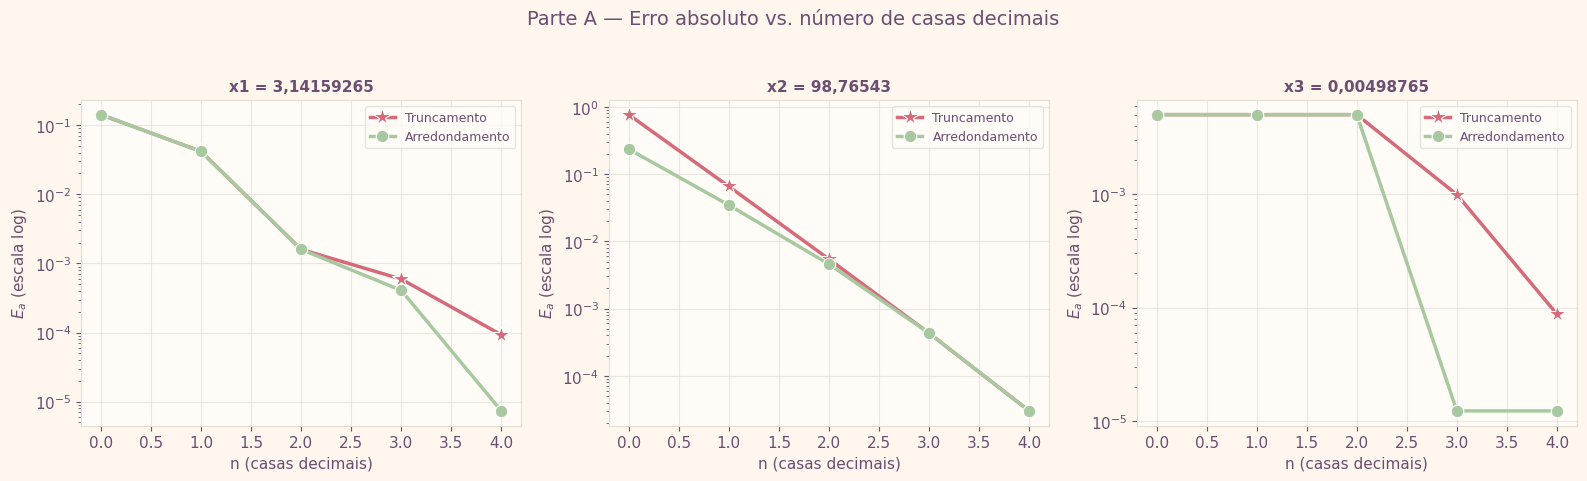

In [3]:
# Um gráfico para cada valor, lado a lado, para comparar o comportamento dos três.
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))

for ax, (nome, x) in zip(axs, valores_A.items()):
    sub = tabela_A[tabela_A["valor"] == nome]   # só as linhas daquele valor
    # Uso semilogy porque o erro cai umas 5 ordens de grandeza de n=0 a n=4;
    # em escala linear as últimas colunas ficariam todas coladas no zero.
    # O .replace(0, 1e-18) é um truque: quando o erro dá exatamente 0, o log
    # não existiria e o ponto sumiria do gráfico.
    ax.semilogy(sub["n"], sub["Ea_trunc"].replace(0, 1e-18), marker="*", markersize=13,
                linewidth=2.5, color=COR_TRUNCADO, label="Truncamento",
                markeredgecolor="white", markeredgewidth=0.8)
    ax.semilogy(sub["n"], sub["Ea_arred"].replace(0, 1e-18), marker="o", markersize=9,
                linewidth=2.5, color=COR_ARREDONDADO, label="Arredondamento",
                markeredgecolor="white", markeredgewidth=0.8)
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel("n (casas decimais)")
    ax.set_ylabel("$E_a$ (escala log)")
    ax.legend(fontsize=9)

plt.suptitle("Parte A — Erro absoluto vs. número de casas decimais",
             fontsize=14, y=1.04)
plt.tight_layout()   # evita que os rótulos de um gráfico invadam o vizinho
plt.savefig("parteA_erro_absoluto.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Arredondar sempre dá um erro igual ou menor do que truncar,
ao arredondar a gente pega o valor mais próximo, então o erro máximo é
meio dígito na última casa, truncar simplesmente corta o resto do número,
sem olhar pra qual lado está mais perto, então o erro pode chegar quase
a um dígito inteiro.

No gráfico dá pra ver que a linha do arredondamento fica
sempre igual ou abaixo da linha do truncamento, nos três valores, as
duas curvas só se encostam quando o primeiro algarismo cortado é menor
que 5, aí tanto faz arredondar ou truncar, dá no mesmo.

## Parte B — Medidas de pressão arterial

Dez medidas de pressão sistólica (mmHg). A referência é a média com
todos os algarismos originais.

In [4]:
medidas = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

# As três versões dos mesmos dados: original, arredondada e truncada para inteiro.
serie_original = medidas
serie_arredondada = np.array([round(v) for v in medidas])
serie_truncada = np.array([trunc(v) for v in medidas])

# A referência de comparação é a média dos dados originais
media_ref = serie_original.mean()


def resumo(serie, nome):
    """Estatísticas de uma série + os erros da média dela em relação à referência.
    Fiz como função para não repetir o mesmo bloco de contas três vezes."""
    return {
        "série": nome,
        "média": serie.mean(),
        "mínimo": serie.min(),
        "máximo": serie.max(),
        "amplitude": serie.max() - serie.min(),
        # ddof=1 = desvio padrão amostral: são 10 medidas de uma amostra,
        # não a população inteira.
        "desvio_padrão_amostral": serie.std(ddof=1),
        "Ea_media": erro_absoluto(media_ref, serie.mean()),
        "Er_media": erro_relativo(media_ref, serie.mean()),
        "E%_media": erro_percentual(media_ref, serie.mean()),
    }


tabela_B = pd.DataFrame([
    resumo(serie_original, "Original"),
    resumo(serie_arredondada, "Arredondada (inteiro)"),
    resumo(serie_truncada, "Truncada (inteiro)"),
])
estiliza_tabela(tabela_B, formato={
    "média": "{:.3f}", "mínimo": "{:.1f}", "máximo": "{:.1f}",
    "amplitude": "{:.1f}", "desvio_padrão_amostral": "{:.3f}",
    "Ea_media": "{:.4f}", "Er_media": "{:.5f}", "E%_media": "{:.3f}",
})

série,média,mínimo,máximo,amplitude,desvio_padrão_amostral,Ea_media,Er_media,E%_media
Original,121.120,119.8,122.4,2.6,0.834,0.0000,0.00000,0.000
Arredondada (inteiro),121.100,120.0,122.0,2.0,0.876,0.0200,0.00017,0.017
Truncada (inteiro),120.700,119.0,122.0,3.0,0.949,0.4200,0.00347,0.347


### Gráfico 1 — as dez medições, três séries

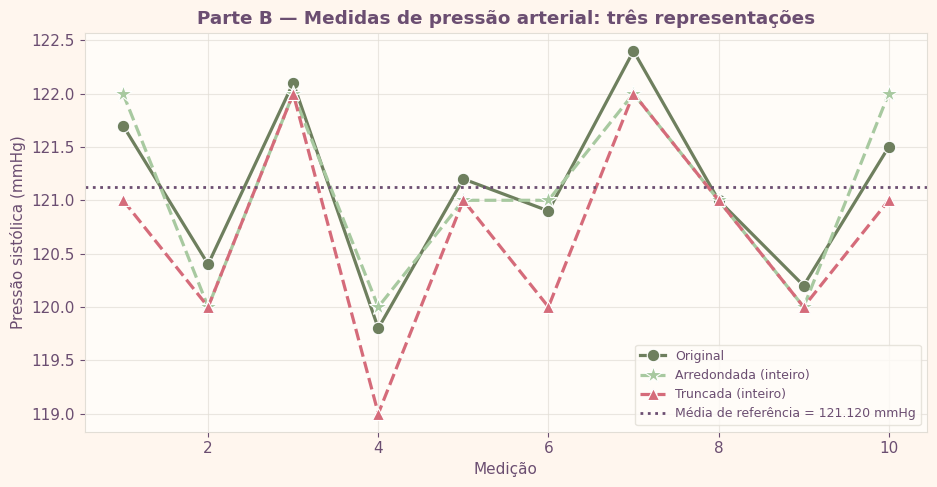

In [ ]:
x_idx = np.arange(1, 11)   # eixo x = número da medição (1 a 10)

plt.figure(figsize=(9.5, 5))
plt.plot(x_idx, serie_original, marker="o", markersize=9, linewidth=2.3, color=COR_ORIGINAL,
         label="Original", markeredgecolor="white", markeredgewidth=0.8)
# As séries aproximadas vão tracejadas e com marcadores diferentes: como elas
# ficam quase em cima da original, sem isso não daria para distinguir as três.
plt.plot(x_idx, serie_arredondada, marker="*", markersize=13, linewidth=2.3, linestyle="--",
         color=COR_ARREDONDADO, label="Arredondada (inteiro)", markeredgecolor="white", markeredgewidth=0.8)
plt.plot(x_idx, serie_truncada, marker="^", markersize=9, linewidth=2.3, linestyle="--",
         color=COR_TRUNCADO, label="Truncada (inteiro)", markeredgecolor="white", markeredgewidth=0.8)
# Linha horizontal na média de referência, para ver o espalhamento em volta dela.
plt.axhline(media_ref, color=COR_REF, linestyle=":", linewidth=2,
            label=f"Média de referência = {media_ref:.3f} mmHg")
plt.xlabel("Medição")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("Parte B — Medidas de pressão arterial: três representações")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("parteB_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 2 e 3 — erros absoluto e percentual da média

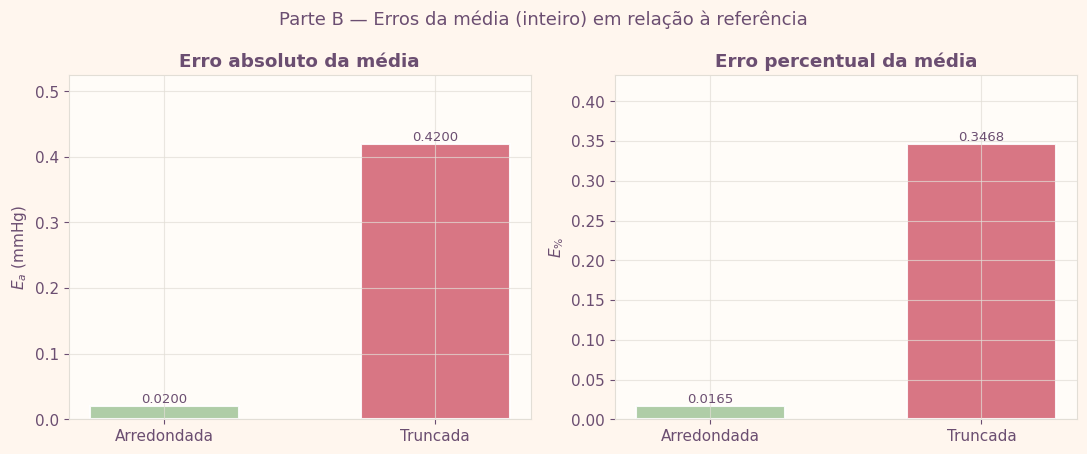

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))

series_nomes = ["Arredondada", "Truncada"]
cores_bar = [COR_ARREDONDADO, COR_TRUNCADO]
# Linha 0 da tabela é a série original (erro zero), por isso pego só as linhas 1 e 2.
Ea_vals = [tabela_B.loc[1, "Ea_media"], tabela_B.loc[2, "Ea_media"]]
Ep_vals = [tabela_B.loc[1, "E%_media"], tabela_B.loc[2, "E%_media"]]

for ax, valores, titulo, rotulo, fmt in [
    (axs[0], Ea_vals, "Erro absoluto da média", "$E_a$ (mmHg)", "{:.4f}"),
    (axs[1], Ep_vals, "Erro percentual da média", "$E_\\%$", "{:.4f}"),
]:
    barras = ax.bar(series_nomes, valores, color=cores_bar, edgecolor="white",
                    linewidth=1.5, alpha=0.92, width=0.55)
    # Escrevo o valor em cima de cada barra: os dois erros são muito diferentes
    # de tamanho e só pelo eixo fica difícil ler o número exato.
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=9.5, color=COR_REF)
    ax.set_ylim(0, max(valores) * 1.25)   # espaço extra em cima para o rótulo caber
    ax.set_title(titulo)
    ax.set_ylabel(rotulo)

plt.suptitle("Parte B — Erros da média (inteiro) em relação à referência", fontsize=13)
plt.tight_layout()
plt.savefig("parteB_erros_media.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 4 — histogramas

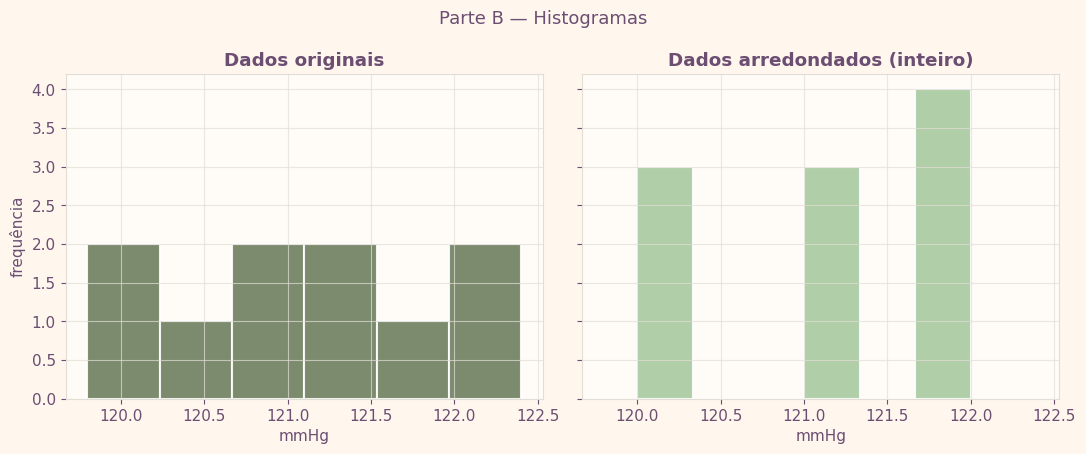

In [ ]:
# Histogramas com o mesmo número de caixas (bins) e o mesmo eixo x nos dois,
# senão a comparação entre "antes" e "depois" de arredondar ficaria injusta.
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)

axs[0].hist(serie_original, bins=6, color=COR_ORIGINAL, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[0].set_title("Dados originais")
axs[0].set_xlabel("mmHg")
axs[0].set_ylabel("frequência")

axs[1].hist(serie_arredondada, bins=6, color=COR_ARREDONDADO, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[1].set_title("Dados arredondados (inteiro)")
axs[1].set_xlabel("mmHg")

plt.suptitle("Parte B — Histogramas", fontsize=13)
plt.tight_layout()
plt.savefig("parteB_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Pra essa amostra pequena, arredondar pra inteiro quase não muda a média
(o erro fica bem abaixo de 0,1%) e a distribuição continua com a mesma
cara, o problema é a perda de detalhe: 121,0 e 121,2, por exemplo, viram
o mesmo número depois de arredondar, o que achata um pouco o
desvio-padrão e a amplitude, então inteiro serve bem se você só quer uma
estimativa rápida da média, mas perde a variação fina que os dados
originais tinham. (Isso é só sobre a representação numérica, sem entrar
em interpretação médica dos valores.)

## Parte C — Vazão em um tubo de pequeno diâmetro

Equação de Hagen–Poiseuille: $Q = \dfrac{\pi r^4 \Delta p}{8 \mu L}$

In [6]:
def vazao_hagen_poiseuille(r, delta_p, mu, L):
    """Vazão Q pela equação de Hagen–Poiseuille.

    Atenção: aqui é tudo em SI — r e L em metros, delta_p em Pa, mu em Pa·s.
    Sempre que eu tiver o raio em mm ou nm, converto antes de chamar.
    """
    return (pi * r**4 * delta_p) / (8 * mu * L)


# Valores de referência do enunciado (o raio vem em mm, por isso o *1e-3).
r0_mm, L0, mu0, dp0 = 0.80, 0.20, 3.5e-3, 1200.0
r0 = r0_mm * 1e-3
Q_ref = vazao_hagen_poiseuille(r0, dp0, mu0, L0)
print(f"Q de referência = {Q_ref:.6e} m^3/s")

Q de referência = 2.757421e-07 m^3/s


### C.1 — Precisão das variáveis

In [ ]:
# Aqui eu bagunço uma variável de cada vez para ver qual delas mais estraga o Q.
r_arred_mm, r_trunc_mm = arredondar(r0_mm, 1), truncar(r0_mm, 1)
mu_arred, mu_trunc = arredondar(mu0, 3), truncar(mu0, 3)
# Para o Δp o enunciado pede na centena mais próxima: divido por 100,
# arredondo/trunco e multiplico de volta.
dp_arred = round(dp0 / 100) * 100
dp_trunc = trunc(dp0 / 100) * 100

# Cada cenário guarda a trinca (r, Δp, μ) que vai entrar na fórmula.
cenarios_C1 = {
    "1. Todos os valores fornecidos": (r0_mm, dp0, mu0),
    "2a. r arredondado (1 casa, mm)": (r_arred_mm, dp0, mu0),
    "2b. r truncado (1 casa, mm)": (r_trunc_mm, dp0, mu0),
    "3a. mu arredondada (3 casas)": (r0_mm, dp0, mu_arred),
    "3b. mu truncada (3 casas)": (r0_mm, dp0, mu_trunc),
    "4a. dp arredondada (centena)": (r0_mm, dp_arred, mu0),
    "4b. dp truncada (centena)": (r0_mm, dp_trunc, mu0),
    "5a. Todas arredondadas": (r_arred_mm, dp_arred, mu_arred),
    "5b. Todas truncadas": (r_trunc_mm, dp_trunc, mu_trunc),
}

linhas_C1 = []
for nome, (r_mm, dp, mu) in cenarios_C1.items():
    Q = vazao_hagen_poiseuille(r_mm * 1e-3, dp, mu, L0)   # mm -> m aqui
    linhas_C1.append({
        "cenário": nome, "r (mm)": r_mm, "Δp (Pa)": dp, "μ (Pa·s)": mu,
        "Q (m³/s)": Q, "Ea": erro_absoluto(Q_ref, Q),
        "Er": erro_relativo(Q_ref, Q), "E% ": erro_percentual(Q_ref, Q),
    })

tabela_C1 = pd.DataFrame(linhas_C1)
estiliza_tabela(tabela_C1, formato={
    "r (mm)": "{:.4f}", "Δp (Pa)": "{:.0f}", "μ (Pa·s)": "{:.4f}",
    "Q (m³/s)": "{:.4e}", "Ea": "{:.4e}", "Er": "{:.5f}", "E% ": "{:.3f}",
})

cenário,r (mm),Δp (Pa),μ (Pa·s),Q (m³/s),Ea,Er,E%
1. Todos os valores fornecidos,0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
"2a. r arredondado (1 casa, mm)",0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
"2b. r truncado (1 casa, mm)",0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
3a. mu arredondada (3 casas),0.8000,1200,0.0040,2.4127e-07,3.4468e-08,0.12500,12.500
3b. mu truncada (3 casas),0.8000,1200,0.0030,3.2170e-07,4.5957e-08,0.16667,16.667
4a. dp arredondada (centena),0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
4b. dp truncada (centena),0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
5a. Todas arredondadas,0.8000,1200,0.0040,2.4127e-07,3.4468e-08,0.12500,12.500
5b. Todas truncadas,0.8000,1200,0.0030,3.2170e-07,4.5957e-08,0.16667,16.667


### C.2 — Sensibilidade de Q ao raio

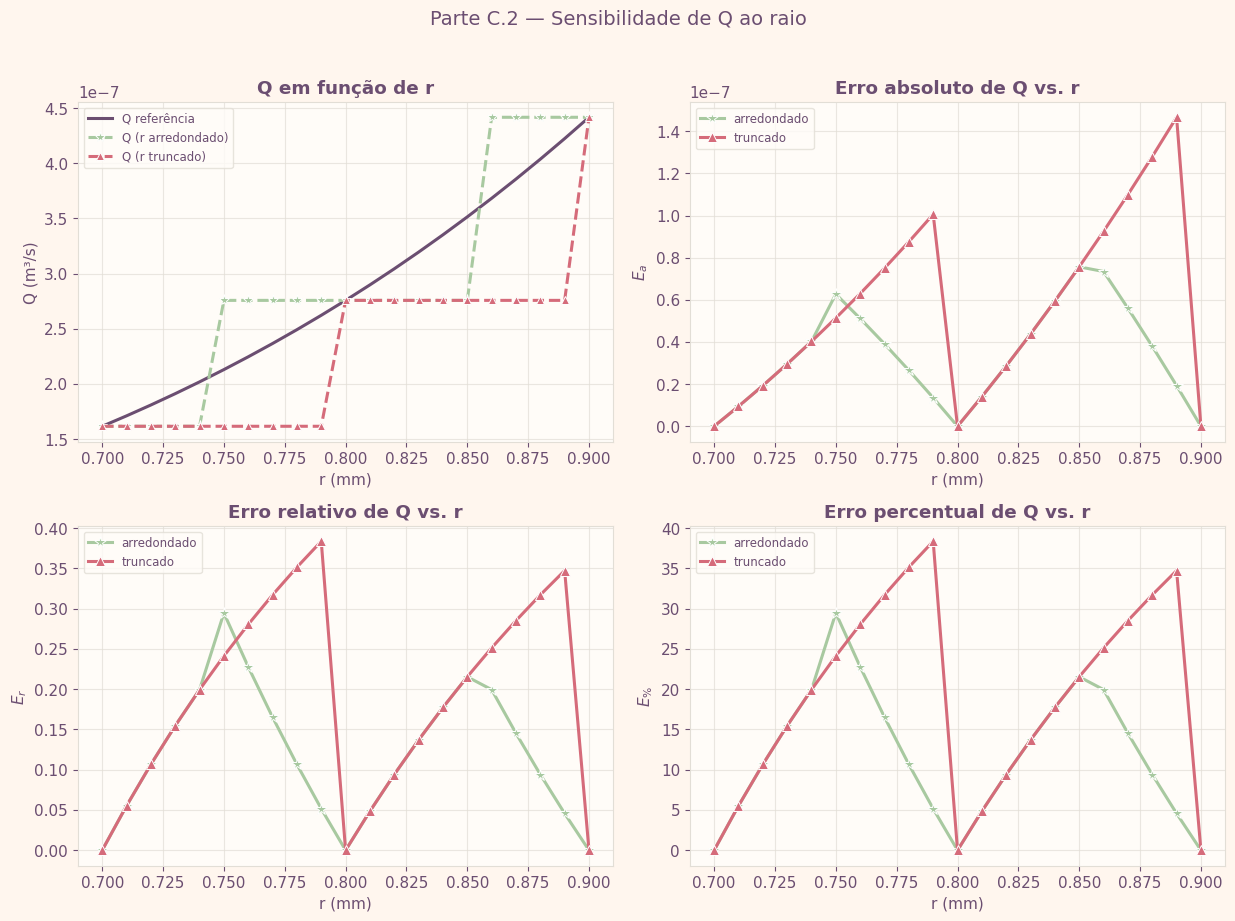

In [7]:
# Varro o raio de 0,70 a 0,90 mm de 0,01 em 0,01 e calculo Q de três jeitos:
# com o raio exato, com o raio arredondado numa casa e com o raio truncado.
r_vals_mm = np.arange(0.70, 0.901, 0.01)
Q_ref_r = np.array([vazao_hagen_poiseuille(r * 1e-3, dp0, mu0, L0) for r in r_vals_mm])
Q_arred_r = np.array([vazao_hagen_poiseuille(arredondar(r, 1) * 1e-3, dp0, mu0, L0) for r in r_vals_mm])
Q_trunc_r = np.array([vazao_hagen_poiseuille(truncar(r, 1) * 1e-3, dp0, mu0, L0) for r in r_vals_mm])

# Os três erros, calculados de uma vez para o vetor inteiro (numpy faz elemento a elemento).
Ea_arred_r = np.abs(Q_ref_r - Q_arred_r)
Ea_trunc_r = np.abs(Q_ref_r - Q_trunc_r)
Er_arred_r = Ea_arred_r / np.abs(Q_ref_r)
Er_trunc_r = Ea_trunc_r / np.abs(Q_ref_r)
Ep_arred_r = 100 * Er_arred_r
Ep_trunc_r = 100 * Er_trunc_r

fig, axs = plt.subplots(2, 2, figsize=(12.5, 9))
mk = dict(markeredgecolor="white", markeredgewidth=0.7, linewidth=2.2)  # estilo repetido

axs[0, 0].plot(r_vals_mm, Q_ref_r, "-", color=COR_REF, linewidth=2.2, label="Q referência")
axs[0, 0].plot(r_vals_mm, Q_arred_r, "--", color=COR_ARREDONDADO, marker="*", markersize=8, label="Q (r arredondado)", **mk)
axs[0, 0].plot(r_vals_mm, Q_trunc_r, "--", color=COR_TRUNCADO, marker="^", markersize=6, label="Q (r truncado)", **mk)
axs[0, 0].set_title("Q em função de r")
axs[0, 0].set_xlabel("r (mm)"); axs[0, 0].set_ylabel("Q (m³/s)"); axs[0, 0].legend(fontsize=8.5)

# Os três erros nos outros quadros: absoluto, relativo e percentual.
# Repare no "degrau": enquanto o arredondamento não muda de casa, o erro cresce
# junto com r; quando ele pula para o próximo valor, o erro despenca.
axs[0, 1].plot(r_vals_mm, Ea_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[0, 1].plot(r_vals_mm, Ea_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[0, 1].set_title("Erro absoluto de Q vs. r")
axs[0, 1].set_xlabel("r (mm)"); axs[0, 1].set_ylabel("$E_a$"); axs[0, 1].legend(fontsize=8.5)

axs[1, 0].plot(r_vals_mm, Er_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[1, 0].plot(r_vals_mm, Er_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[1, 0].set_title("Erro relativo de Q vs. r")
axs[1, 0].set_xlabel("r (mm)"); axs[1, 0].set_ylabel("$E_r$"); axs[1, 0].legend(fontsize=8.5)

axs[1, 1].plot(r_vals_mm, Ep_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[1, 1].plot(r_vals_mm, Ep_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[1, 1].set_title("Erro percentual de Q vs. r")
axs[1, 1].set_xlabel("r (mm)"); axs[1, 1].set_ylabel("$E_\\%$"); axs[1, 1].legend(fontsize=8.5)

plt.suptitle("Parte C.2 — Sensibilidade de Q ao raio", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("parteC_sensibilidade_raio.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Como Q depende de r elevado à quarta, um erro pequeno no raio vira um
erro bem maior em Q, quase 4 vezes maior, proporcionalmente
($\Delta Q/Q \approx 4 \cdot \Delta r/r$), é por isso que só arredondar
o raio numa casa decimal já aumenta bastante o erro percentual de Q,
mesmo o erro no raio em si sendo pequeno, dá pra ver isso nos gráficos
acima.

## Parte D — Escoamento em um nanocateter

Modelo didático: $r = 50$ nm, $L = 10$ µm, $\mu = 3{,}5\times10^{-3}$ Pa·s,
$\Delta p = 5000$ Pa.

In [12]:
# Mesma equação da Parte C, só que agora numa escala muito menor:
# nanômetros (1e-9 m) e micrômetros (1e-6 m).
r_nano_nm, L_nano_um, mu_nano, dp_nano = 50.0, 10.0, 3.5e-3, 5000.0
r_nano = r_nano_nm * 1e-9   # nm -> m
L_nano = L_nano_um * 1e-6   # µm -> m

Q_nano_ref = vazao_hagen_poiseuille(r_nano, dp_nano, mu_nano, L_nano)
print(f"Q(r=50nm) de referência = {Q_nano_ref:.6e} m^3/s")

Q(r=50nm) de referência = 3.506242e-19 m^3/s


### D.1 — Erro geométrico

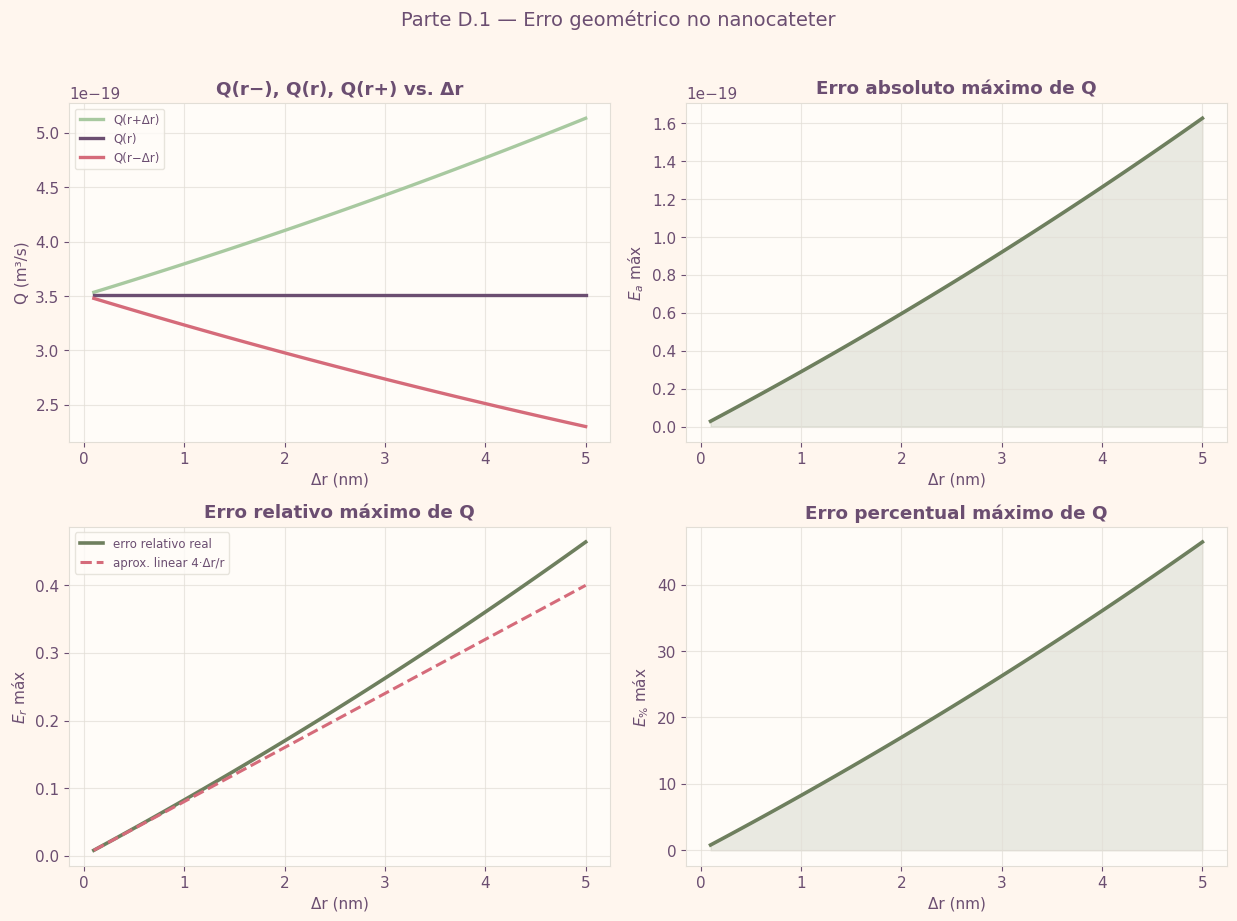

Erro relativo real em Δr=5nm: 0.46410  |  Aproximação linear: 0.40000


In [13]:
# Suponho uma incerteza Δr no raio, de 0,1 até 5 nm, e vejo o quanto Q muda
# para mais (r+Δr) e para menos (r-Δr).
delta_r_nm = np.arange(0.1, 5.01, 0.1)
r_menos_nm = r_nano_nm - delta_r_nm
r_mais_nm = r_nano_nm + delta_r_nm

Q_menos = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_menos_nm])
Q_mais = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_mais_nm])
Q_nano_const = np.full_like(delta_r_nm, Q_nano_ref)   # linha reta de referência

# Fico com o pior dos dois casos (o maior desvio) para cada Δr.
# Como Q ~ r^4 não é simétrica, errar para cima e para baixo não dá o mesmo tanto.
Ea_max_D1 = np.maximum(np.abs(Q_mais - Q_nano_ref), np.abs(Q_menos - Q_nano_ref))
Er_max_D1 = Ea_max_D1 / Q_nano_ref
Ep_max_D1 = 100 * Er_max_D1

# Estimativa teórica pela derivada: dQ/Q ≈ 4·dr/r. Ploto junto para comparar.
aprox_linear = 4 * (delta_r_nm / r_nano_nm)

fig, axs = plt.subplots(2, 2, figsize=(12.5, 9))

axs[0, 0].plot(delta_r_nm, Q_mais, "-", color=COR_ARREDONDADO, linewidth=2.4, label="Q(r+Δr)")
axs[0, 0].plot(delta_r_nm, Q_nano_const, "-", color=COR_REF, linewidth=2.4, label="Q(r)")
axs[0, 0].plot(delta_r_nm, Q_menos, "-", color=COR_TRUNCADO, linewidth=2.4, label="Q(r−Δr)")
axs[0, 0].set_title("Q(r−), Q(r), Q(r+) vs. Δr")
axs[0, 0].set_xlabel("Δr (nm)"); axs[0, 0].set_ylabel("Q (m³/s)"); axs[0, 0].legend(fontsize=8.5)

# O fill_between é só estético: ajuda a enxergar que a área de erro vai crescendo.
axs[0, 1].plot(delta_r_nm, Ea_max_D1, color=COR_ORIGINAL, linewidth=2.6)
axs[0, 1].fill_between(delta_r_nm, Ea_max_D1, color=COR_ORIGINAL, alpha=0.15)
axs[0, 1].set_title("Erro absoluto máximo de Q")
axs[0, 1].set_xlabel("Δr (nm)"); axs[0, 1].set_ylabel("$E_a$ máx")

axs[1, 0].plot(delta_r_nm, Er_max_D1, color=COR_ORIGINAL, linewidth=2.6, label="erro relativo real")
axs[1, 0].plot(delta_r_nm, aprox_linear, "--", color=COR_TRUNCADO, linewidth=2.2, label="aprox. linear 4·Δr/r")
axs[1, 0].set_title("Erro relativo máximo de Q")
axs[1, 0].set_xlabel("Δr (nm)"); axs[1, 0].set_ylabel("$E_r$ máx"); axs[1, 0].legend(fontsize=8.5)

axs[1, 1].plot(delta_r_nm, Ep_max_D1, color=COR_ORIGINAL, linewidth=2.6)
axs[1, 1].fill_between(delta_r_nm, Ep_max_D1, color=COR_ORIGINAL, alpha=0.15)
axs[1, 1].set_title("Erro percentual máximo de Q")
axs[1, 1].set_xlabel("Δr (nm)"); axs[1, 1].set_ylabel("$E_\\%$ máx")

plt.suptitle("Parte D.1 — Erro geométrico no nanocateter", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("parteD1_erro_geometrico.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Erro relativo real em Δr=5nm: {Er_max_D1[-1]:.5f}  |  Aproximação linear: {aprox_linear[-1]:.5f}")

Pra Δr pequeno, a aproximação linear (4·Δr/r) bate quase certinho com o
erro real, conforme Δr cresce, ela vai ficando um pouco abaixo do valor
real, porque essa fórmula ignora os termos de ordem maior que vêm do r⁴, funciona bem como estimativa rápida, mas não é exata pra variações
grandes.

### D.2 — Precisão computacional (float32 vs float64)

In [14]:
# Aqui o erro não vem mais de arredondar "na mão", e sim de como o computador
# guarda o número. Calculo o mesmo Q com precisão simples e dupla.
r32, r64 = np.float32(r_nano), np.float64(r_nano)
dp32, dp64 = np.float32(dp_nano), np.float64(dp_nano)
mu32, mu64 = np.float32(mu_nano), np.float64(mu_nano)
L32, L64 = np.float32(L_nano), np.float64(L_nano)

# Separei o r^4 porque é ele que mais sofre: elevar à quarta multiplica o
# errinho de representação do raio por ~4.
r4_32 = r32**4
r4_64 = r64**4
Q_32 = vazao_hagen_poiseuille(r32, dp32, mu32, L32)
Q_64 = vazao_hagen_poiseuille(r64, dp64, mu64, L64)

# Tomo o float64 como "valor certo" e vejo o quanto o float32 se afasta dele.
diff_abs = abs(float(Q_64) - float(Q_32))
diff_rel = diff_abs / abs(float(Q_64))

# eps = menor número que, somado a 1, ainda muda o resultado naquele tipo.
# É a "resolução" de cada precisão.
tabela_D2 = pd.DataFrame([{
    "r^4 (float32)": r4_32, "r^4 (float64)": r4_64,
    "Q (float32)": Q_32, "Q (float64)": Q_64,
    "|ΔQ| abs": diff_abs, "|ΔQ| rel": diff_rel,
    "eps float32": np.finfo(np.float32).eps, "eps float64": np.finfo(np.float64).eps,
}])
estiliza_tabela(tabela_D2, formato="{:.4e}")

r^4 (float32),r^4 (float64),Q (float32),Q (float64),|ΔQ| abs,|ΔQ| rel,eps float32,eps float64
6.2500e-30,6.2500e-30,3.5062e-19,3.5062e-19,5.2286e-26,1.4912e-07,1.1921e-07,2.2204e-16


### Cancelamento numérico: δ1 (expressão direta) vs. δ2 (expandida)

In [15]:
# Duas maneiras matematicamente equivalentes de calcular a variação relativa de Q
# quando o raio muda de r para r+Δr. Na teoria dão o mesmo número; no computador, não.
razoes = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8])


def delta1(dtype, razao):
    """Jeito direto: calcula os dois Q e subtrai. É aqui que mora o problema —
    para razões pequenas, Q(r+Δr) e Q(r) são quase idênticos e a subtração
    joga fora quase todos os dígitos bons (cancelamento catastrófico)."""
    r = dtype(r_nano); dr = dtype(r_nano * razao)
    Q_r = vazao_hagen_poiseuille(r, dtype(dp_nano), dtype(mu_nano), dtype(L_nano))
    Q_rdr = vazao_hagen_poiseuille(r + dr, dtype(dp_nano), dtype(mu_nano), dtype(L_nano))
    return (Q_rdr - Q_r) / Q_r


def delta2(dtype, razao):
    """Jeito reescrito: como tudo que não é r se cancela, sobra (1+x)^4 - 1.
    Os números envolvidos ficam pequenos, então sobra mais precisão."""
    return (dtype(1) + dtype(razao)) ** 4 - dtype(1)


linhas_D2b = []
for razao in razoes:
    # Rodo as duas expressões nas duas precisões para comparar os quatro casos.
    d1_32, d1_64 = delta1(np.float32, razao), delta1(np.float64, razao)
    d2_32, d2_64 = delta2(np.float32, razao), delta2(np.float64, razao)
    linhas_D2b.append({
        "Δr/r": razao,
        "δ1 (float32)": float(d1_32), "δ2 (float32)": float(d2_32),
        "diff float32": abs(float(d1_32) - float(d2_32)),
        "δ1 (float64)": float(d1_64), "δ2 (float64)": float(d2_64),
        "diff float64": abs(float(d1_64) - float(d2_64)),
    })

tabela_D2b = pd.DataFrame(linhas_D2b)
estiliza_tabela(tabela_D2b, formato={
    "Δr/r": "{:.0e}", "δ1 (float32)": "{:.6e}", "δ2 (float32)": "{:.6e}",
    "diff float32": "{:.2e}", "δ1 (float64)": "{:.6e}", "δ2 (float64)": "{:.6e}",
    "diff float64": "{:.2e}",
})

Δr/r,δ1 (float32),δ2 (float32),diff float32,δ1 (float64),δ2 (float64),diff float64
1e-01,4.641001e-01,4.641001e-01,5.96e-08,4.641000e-01,4.641000e-01,2.22e-16
1e-02,4.060375e-02,4.060400e-02,2.50e-07,4.060401e-02,4.060401e-02,1.04e-16
1e-03,4.006010e-03,4.006147e-03,1.37e-07,4.006004e-03,4.006004e-03,2.21e-16
1e-04,3.998786e-04,4.001856e-04,3.07e-07,4.000600e-04,4.000600e-04,1.24e-16
1e-05,4.010581e-05,4.005432e-05,5.15e-08,4.000060e-05,4.000060e-05,2.27e-16
1e-06,3.907368e-06,3.814697e-06,9.27e-08,4.000006e-06,4.000006e-06,5.36e-16
1e-07,2.211718e-07,4.768372e-07,2.56e-07,4.000001e-07,4.000001e-07,1.87e-16
1e-08,0.000000e+00,0.000000e+00,0.00e+00,4.000000e-08,4.000000e-08,3.17e-16


Quando Δr/r fica bem pequeno, δ1 está subtraindo dois números quase
iguais (Q(r+Δr) e Q(r))e isso faz perder precisão (o famoso
cancelamento catastrófico). Isso aparece primeiro no float32, que tem
menos casas decimais disponíveis (eps maior); no float64 só acontece
pra razões ainda menores, a δ2, calculada de outro jeito, sofre um
cancelamento parecido no final da conta, mas costuma preservar mais
dígitos porque os números envolvidos ficam menores no meio do caminho.

### D.3 — Fenômeno físico

Quando o canal fica tão pequeno assim, nanômetros em vez de milímetros, a razão entre superfície e volume aumenta bastante, o
volume cresce com r², mas o contato com a parede cresce com r, então
quanto menor o raio, maior a fatia do fluido que fica perto da parede e é bem ali que a velocidade do fluido é freada (a condição de
não-deslizamento). Por isso, na escala do nanocateter, os efeitos de
parede e a viscosidade pesam muito mais do que num tubo comum.


## GIF demonstrativo — o nanocateter "respirando"

A ideia é mostrar, animado, o que a Parte D.1 mostra em gráfico: como um
errinho no raio mexe na vazão. São **41 quadros** com o raio indo de 45 a 55 nm.
Cada quadro tem a seção transversal do canal (com o círculo de referência de
50 nm tracejado) e a curva $Q \times r$ sendo construída aos poucos.

**Como o GIF é feito, na prática:**

1. `matplotlib` desenha **um quadro por vez** (uma figura normal, com dois gráficos);
2. em vez de salvar 41 arquivos PNG no disco, salvo cada figura em um buffer de
   memória com `io.BytesIO()` e leio de volta como imagem (`imageio.imread`);
3. no fim, `imageio.mimsave()` costura a lista de imagens em um único `.gif`,
   com `duration=0.12` (o tempo de cada quadro) e `loop=0` (repete pra sempre).

Também deixei a função `desenha_secao()` separada, porque **uso ela duas vezes**:
nos quadros do GIF e depois no painel da Parte E, para o quadro estático.

In [16]:
def desenha_secao(ax, r_atual, r_ref=50.0):
    """Desenha a seção transversal do canal (um corte do nanocateter visto de frente).

    Fiz como função porque uso o mesmo desenho no GIF e no painel da Parte E.
    - círculo cheio  = raio atual
    - círculo tracejado = raio de referência (50 nm)
    - o "brilho" em volta é só enfeite, ajuda o círculo a não ficar seco no fundo
    """
    ax.set_facecolor("#FFF7FB")
    ax.grid(False)
    ax.add_patch(Circle((0, 0), r_atual * 1.15, color=COR_ARREDONDADO, alpha=0.18))
    ax.add_patch(Circle((0, 0), r_atual, color=COR_TRUNCADO, alpha=0.80, ec="white", lw=2))
    ax.add_patch(Circle((0, 0), r_ref, fill=False, ls="--", color=COR_REF, lw=1.3))
    # setinha do raio, saindo do centro
    ax.annotate("", xy=(r_atual, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=COR_REF, lw=1.5))
    ax.text(r_atual / 2, 3.5, "r", fontsize=11, color=COR_REF, fontweight="bold")
    ax.plot(0, 0, marker="*", markersize=13, color=COR_APOIO,
            markeredgecolor="white", markeredgewidth=0.6)
    # limites fixos e aspecto igual: sem isso o círculo vira elipse e, pior,
    # ele "pularia" de tamanho de um quadro para o outro no GIF.
    ax.set_xlim(-62, 62); ax.set_ylim(-62, 62)
    ax.set_aspect("equal")
    ax.set_xlabel("nm"); ax.set_ylabel("nm")


# Os 41 valores de raio da animação e o Q de cada um.
r_gif = np.linspace(45, 55, 41)
Q_gif = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_gif])
Ep_gif = 100 * np.abs(Q_gif - Q_nano_ref) / Q_nano_ref   # erro % em relação a r = 50 nm

frames = []   # lista de imagens que vira o GIF no final

for i in range(len(r_gif)):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.6), dpi=110)
    fig.patch.set_facecolor("#FFF7FB")

    # --- quadro da esquerda: a seção transversal ---
    ax_c = axs[0]
    desenha_secao(ax_c, r_gif[i])
    ax_c.set_title("Seção transversal do canal", fontsize=11)
    ax_c.text(0, -57, f"r = {r_gif[i]:.2f} nm    Q = {Q_gif[i]:.3e} m³/s\n"
                      f"E% em relação a r = 50 nm: {Ep_gif[i]:.2f}%",
              ha="center", va="center", fontsize=8.5, color=COR_REF,
              bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF0F7",
                        edgecolor=COR_REF, linewidth=0.8))

    # --- quadro da direita: a curva Q x r crescendo ---
    ax_q = axs[1]
    # o [:i+1] é o truque da animação: a cada quadro desenho só o pedaço da
    # curva que já "aconteceu", então ela parece estar sendo traçada na hora.
    ax_q.plot(r_gif[:i + 1], Q_gif[:i + 1], "-", color=COR_ARREDONDADO, linewidth=2.4)
    ax_q.plot(r_gif[i], Q_gif[i], marker="*", markersize=15, color=COR_APOIO,
              markeredgecolor="white", markeredgewidth=0.8,
              path_effects=[pe.withStroke(linewidth=3, foreground=COR_REF, alpha=0.15)])
    ax_q.axvline(50, color=COR_REF, linestyle=":", linewidth=1.3)
    # limites fixos também aqui, senão o eixo se reajusta a cada quadro e o GIF treme.
    ax_q.set_xlim(44, 56)
    ax_q.set_ylim(Q_gif.min() * 0.95, Q_gif.max() * 1.05)
    ax_q.set_title("Curva Q × r (sendo construída)", fontsize=11)
    ax_q.set_xlabel("r (nm)"); ax_q.set_ylabel("Q (m³/s)")

    plt.suptitle(f"Nanocateter — quadro {i + 1}/{len(r_gif)}",
                 fontsize=12.5, color=COR_REF, fontweight="bold")
    plt.tight_layout()

    # Salvo a figura num "arquivo de mentira" na memória e leio de volta como imagem.
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=110, facecolor=fig.get_facecolor())
    plt.close(fig)          # fecho a figura para não estourar a memória com 41 delas abertas
    buf.seek(0)             # volto o cursor para o começo do buffer antes de ler
    frames.append(imageio.imread(buf))

# duration = tempo de cada quadro (s); loop=0 = repete infinitamente.
imageio.mimsave("nanocateter_demo.gif", frames, duration=0.12, loop=0)
print(f"GIF gerado com {len(frames)} quadros: nanocateter_demo.gif")

GIF gerado com 41 quadros: nanocateter_demo.gif


### Exibindo o GIF aqui no notebook

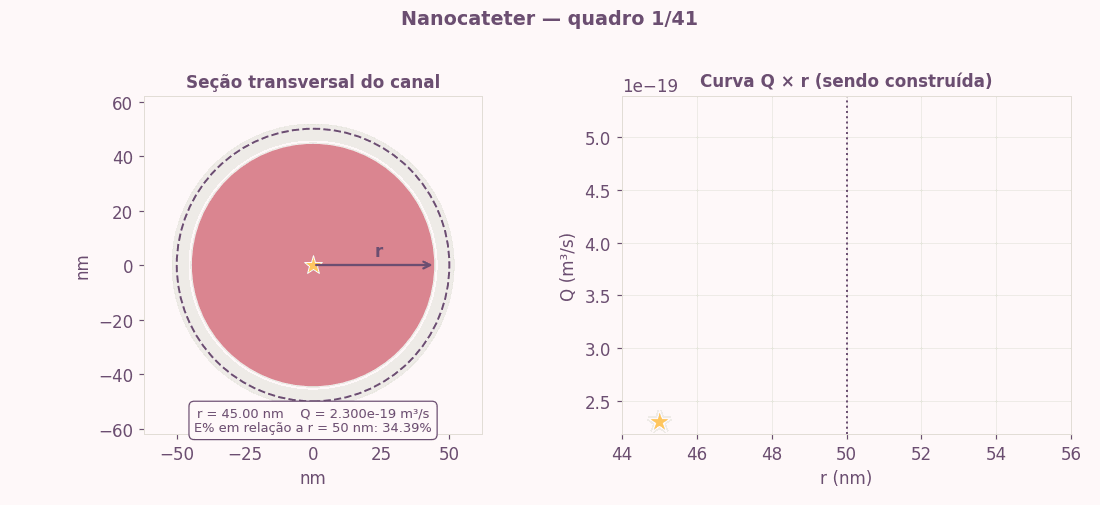

In [ ]:
from IPython.display import Image as IPyImage, display

# O display do IPython mostra o .gif animado dentro da própria saída da célula.
display(IPyImage(filename="nanocateter_demo.gif"))

## Parte E — Síntese visual (PNG único)

Aqui eu junto os resultados principais de todas as partes numa figura só.

**Tamanho da imagem:** o enunciado pede 1600×1000 px, então travei isso no
código em vez de deixar o matplotlib decidir. Como `figsize` é em polegadas e
`dpi` é em pontos por polegada, o tamanho final em pixels é a multiplicação dos
dois: `16 pol × 100 dpi = 1600 px` e `10 pol × 100 dpi = 1000 px`. Dois
detalhes importantes para o número não escapar:

- salvar com o **mesmo** `dpi` da figura (`fig.savefig(..., dpi=DPI)`);
- **não** usar `bbox_inches="tight"` no `savefig`, porque ele recorta as margens
  sobrando e muda o tamanho final.

No fim da célula tem um `assert` conferindo se o PNG saiu mesmo em 1600×1000 —
se um dia eu mexer no código e quebrar isso, ele avisa na hora.

**Como montei o painel:** a figura é dividida por um `GridSpec` de 3 linhas ×
3 colunas — é isso que me deixa dar tamanhos diferentes para cada quadro (o
gráfico da Parte C.2, por exemplo, ocupa duas colunas). Os textos ficam dentro
de caixas arredondadas feitas com `FancyBboxPatch`, e o quadro de baixo à
esquerda reaproveita a função `desenha_secao()` do GIF, para o painel e a
animação contarem a mesma história.

Os espaçamentos (`hspace`, `wspace` e as margens) foram ajustados na mão
para nenhum título ou texto encostar no vizinho nem ficar cortado.

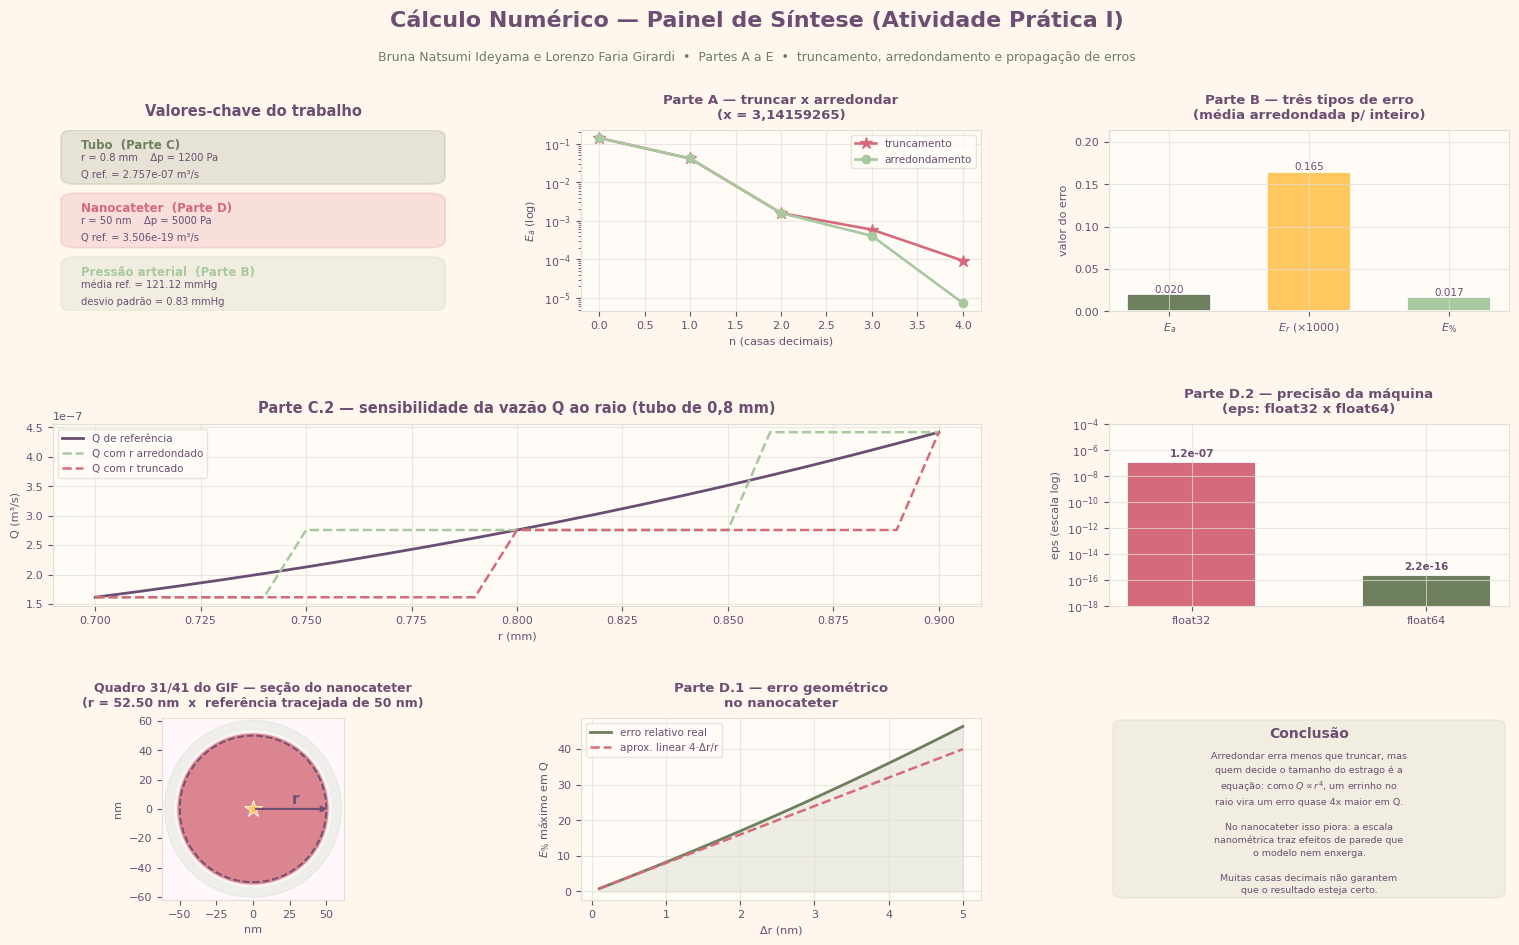

Dimensões do PNG final: 1600 x 1000 px


In [17]:

LARGURA_PX, ALTURA_PX, DPI = 1600, 1000, 100

# Como a figura é menor do que os gráficos soltos do notebook, uso o rc_context
# para diminuir a fonte-base só aqui dentro (fora dele o notebook continua com a
# fonte normal). Sem isso, os rótulos dos eixos ficam gigantes e um invade o outro.
with plt.rc_context({"font.size": 8, "axes.titlesize": 9.5, "legend.fontsize": 7.5}):
    fig = plt.figure(figsize=(LARGURA_PX / DPI, ALTURA_PX / DPI), dpi=DPI)
    fig.patch.set_facecolor(COR_FUNDO)

    # GridSpec = a "planta baixa" do painel: 3 linhas x 3 colunas.
    # hspace/wspace são os respiros entre os quadros e top/bottom/left/right são
    # as margens. Fui ajustando na mão até nenhum título encostar no vizinho.
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.62, wspace=0.32,
                           left=0.06, right=0.97, top=0.845, bottom=0.075)

    fig.suptitle("Cálculo Numérico — Painel de Síntese (Atividade Prática I)",
                 fontsize=16, fontweight="bold", color=COR_REF, y=0.965)
    fig.text(0.5, 0.918,
             "Bruna Natsumi Ideyama e Lorenzo Faria Girardi  •  Partes A a E  •  "
             "truncamento, arredondamento e propagação de erros",
             ha="center", va="center", fontsize=9, color=COR_ORIGINAL)

    # ------------------------------------------------------------ [0,0] cartões
    # Quadro sem gráfico nenhum: só três cartõezinhos com os números principais.
    ax_cards = fig.add_subplot(gs[0, 0])
    ax_cards.axis("off")                   # é um cartaz, não um gráfico
    ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 1)
    ax_cards.set_title("Valores-chave do trabalho", fontsize=10.5, pad=10)

    cartoes = [
        ("Tubo  (Parte C)",
         f"r = {r0_mm} mm    Δp = {dp0:.0f} Pa\nQ ref. = {Q_ref:.3e} m³/s", COR_ORIGINAL),
        ("Nanocateter  (Parte D)",
         f"r = {r_nano_nm:.0f} nm    Δp = {dp_nano:.0f} Pa\nQ ref. = {Q_nano_ref:.3e} m³/s", COR_TRUNCADO),
        ("Pressão arterial  (Parte B)",
         f"média ref. = {media_ref:.2f} mmHg\ndesvio padrão = {serie_original.std(ddof=1):.2f} mmHg", COR_ARREDONDADO),
    ]

    altura = 0.30                          # altura de cada cartão (fração do quadro)
    # Posiciono título e texto sempre a partir do TOPO do cartão (y_topo - 0.09 e
    # y_topo - 0.20). Assim o conteúdo nunca escapa da caixinha, que era o
    # problema da primeira versão do painel.
    for (titulo, texto, cor), y_topo in zip(cartoes, [1.0, 0.65, 0.30]):
        ax_cards.add_patch(FancyBboxPatch(
            (0.02, y_topo - altura), 0.96, altura,
            boxstyle="round,pad=0,rounding_size=0.04", transform=ax_cards.transAxes,
            facecolor=cor, alpha=0.16, edgecolor=cor, linewidth=1.4))
        ax_cards.text(0.07, y_topo - 0.085, titulo, transform=ax_cards.transAxes,
                      fontsize=8.5, fontweight="bold", color=cor, va="center")
        ax_cards.text(0.07, y_topo - 0.20, texto, transform=ax_cards.transAxes,
                      fontsize=7.2, color=COR_REF, va="center", linespacing=1.9)

    # ------------------------------------------------------------- [0,1] Parte A
    ax1 = fig.add_subplot(gs[0, 1])
    sub = tabela_A[tabela_A["valor"] == "x1 = 3,14159265"]     # o π como exemplo
    ax1.semilogy(sub["n"], sub["Ea_trunc"].replace(0, 1e-18), marker="*", markersize=9,
                 linewidth=1.9, color=COR_TRUNCADO, label="truncamento")
    ax1.semilogy(sub["n"], sub["Ea_arred"].replace(0, 1e-18), marker="o", markersize=6,
                 linewidth=1.9, color=COR_ARREDONDADO, label="arredondamento")
    ax1.set_title("Parte A — truncar x arredondar\n(x = 3,14159265)", fontsize=9.5, pad=8)
    ax1.set_xlabel("n (casas decimais)"); ax1.set_ylabel("$E_a$ (log)")
    ax1.legend(loc="upper right")

    # ------------------------------------------------------------- [0,2] Parte B
    ax2 = fig.add_subplot(gs[0, 2])
    # O Er é minúsculo perto dos outros dois, então multipliquei por 1000 só para
    # ele aparecer na mesma escala — está avisado no rótulo do eixo x.
    valores_b = [tabela_B.loc[1, "Ea_media"], tabela_B.loc[1, "Er_media"] * 1000,
                 tabela_B.loc[1, "E%_media"]]
    barras = ax2.bar(["$E_a$", "$E_r$ (×1000)", "$E_\\%$"], valores_b,
                     color=[COR_ORIGINAL, COR_APOIO, COR_ARREDONDADO],
                     edgecolor="white", linewidth=1.2, width=0.6)
    for b, v in zip(barras, valores_b):    # valor escrito em cima de cada barra
        ax2.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center",
                 va="bottom", fontsize=7.5, color=COR_REF)
    ax2.set_ylim(0, max(valores_b) * 1.3)  # folga para o rótulo não ser cortado
    ax2.set_title("Parte B — três tipos de erro\n(média arredondada p/ inteiro)",
                  fontsize=9.5, pad=8)
    ax2.set_ylabel("valor do erro")

    # --------------------------------------------------------- [1, 0:2] Parte C.2
    # gs[1, :2] = ocupa as duas primeiras colunas da linha do meio, porque é uma
    # curva comprida e ficaria espremida em uma coluna só.
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.plot(r_vals_mm, Q_ref_r, "-", color=COR_REF, linewidth=2, label="Q de referência")
    ax3.plot(r_vals_mm, Q_arred_r, "--", color=COR_ARREDONDADO, linewidth=1.8, label="Q com r arredondado")
    ax3.plot(r_vals_mm, Q_trunc_r, "--", color=COR_TRUNCADO, linewidth=1.8, label="Q com r truncado")
    ax3.set_title("Parte C.2 — sensibilidade da vazão Q ao raio (tubo de 0,8 mm)",
                  fontsize=10.5, pad=8)
    ax3.set_xlabel("r (mm)"); ax3.set_ylabel("Q (m³/s)")
    ax3.legend(loc="upper left")

    # ----------------------------------------------------------- [1,2] Parte D.2
    ax4 = fig.add_subplot(gs[1, 2])
    eps_vals = [np.finfo(np.float32).eps, np.finfo(np.float64).eps]
    b4 = ax4.bar(["float32", "float64"], eps_vals, color=[COR_TRUNCADO, COR_ORIGINAL],
                 edgecolor="white", linewidth=1.3, width=0.55)
    # Escala log obrigatória: são 9 ordens de grandeza entre os dois eps.
    ax4.set_yscale("log"); ax4.set_ylim(1e-18, 1e-4)
    for b, v in zip(b4, eps_vals):
        ax4.text(b.get_x() + b.get_width() / 2, v * 2.5, f"{v:.1e}", ha="center",
                 fontsize=7.5, color=COR_REF, fontweight="bold")
    ax4.set_title("Parte D.2 — precisão da máquina\n(eps: float32 x float64)",
                  fontsize=9.5, pad=8)
    ax4.set_ylabel("eps (escala log)")

    # ------------------------------------------------------ [2,0] quadro do GIF
    # Reaproveito a função da animação: aqui congelo um quadro para quem olhar
    # só o PNG entender do que trata o GIF.
    ax5 = fig.add_subplot(gs[2, 0])
    i_quadro = 30
    desenha_secao(ax5, r_gif[i_quadro])
    ax5.set_title(f"Quadro {i_quadro + 1}/{len(r_gif)} do GIF — seção do nanocateter\n"
                  f"(r = {r_gif[i_quadro]:.2f} nm  x  referência tracejada de 50 nm)",
                  fontsize=9, pad=8)

    # ----------------------------------------------------------- [2,1] Parte D.1
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(delta_r_nm, 100 * Er_max_D1, color=COR_ORIGINAL, linewidth=2,
             label="erro relativo real")
    ax6.plot(delta_r_nm, 100 * aprox_linear, "--", color=COR_TRUNCADO, linewidth=1.8,
             label="aprox. linear 4·Δr/r")
    ax6.fill_between(delta_r_nm, 100 * Er_max_D1, color=COR_ORIGINAL, alpha=0.12)
    ax6.set_title("Parte D.1 — erro geométrico\nno nanocateter", fontsize=9.5, pad=8)
    ax6.set_xlabel("Δr (nm)"); ax6.set_ylabel("$E_\\%$ máximo em Q")
    ax6.legend(loc="upper left")

    # ---------------------------------------------------------- [2,2] conclusão
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis("off")
    ax7.set_xlim(0, 1); ax7.set_ylim(0, 1)
    ax7.add_patch(FancyBboxPatch((0.01, 0.01), 0.98, 0.98,
                  boxstyle="round,pad=0,rounding_size=0.03", transform=ax7.transAxes,
                  facecolor=COR_ARREDONDADO, alpha=0.16, edgecolor=COR_ARREDONDADO,
                  linewidth=1.4, zorder=0))
    ax7.text(0.5, 0.915, "Conclusão", fontsize=10, fontweight="bold", color=COR_REF,
             transform=ax7.transAxes, ha="center", va="center")
    # Quebrei as linhas na mão e centralizei tudo (ha/va = "center") para o texto
    # ficar certinho dentro da caixa em vez de vazar pelas bordas.
    ax7.text(0.5, 0.42,
             "Arredondar erra menos que truncar, mas\n"
             "quem decide o tamanho do estrago é a\n"
             "equação: como $Q \\propto r^4$, um errinho no\n"
             "raio vira um erro quase 4x maior em Q.\n\n"
             "No nanocateter isso piora: a escala\n"
             "nanométrica traz efeitos de parede que\n"
             "o modelo nem enxerga.\n\n"
             "Muitas casas decimais não garantem\n"
             "que o resultado esteja certo.",
             fontsize=6.8, color=COR_REF, transform=ax7.transAxes,
             ha="center", va="center", linespacing=1.5)

    # Salvo com o MESMO dpi da figura e SEM bbox_inches="tight" — o "tight"
    # recorta as margens que sobram e mudaria o tamanho final, que é justamente
    # o que não pode acontecer aqui.
    fig.savefig("parteE_painel_sintese.png", dpi=DPI, facecolor=COR_FUNDO)
    plt.show()

# Confirmação do tamanho, para não ter surpresa na hora de entregar.
tamanho = Image.open("parteE_painel_sintese.png").size
print(f"Dimensões do PNG final: {tamanho[0]} x {tamanho[1]} px")
assert tamanho == (LARGURA_PX, ALTURA_PX), "O PNG saiu com tamanho diferente do pedido!"

## Conclusão

O truncamento e o arredondamento causam erros pequenos por si só, mas
como eles se propagam depende muito da equação, na pressão arterial, a
propagação é quase linear, então arredondar pra inteiro quase não muda
nada, já em Hagen–Poiseuille, como Q depende de r⁴, qualquer erro no
raio vira um erro bem maior em Q e isso pesa ainda mais na escala do
nanocateter, onde a física de parede também entra em jogo.

A comparação entre `float32` e `float64` mostra outro tipo de limite:
mesmo sem nenhum erro de arredondamento "manual", o computador já tem
sua própria precisão limitada, e comparar δ1 com δ2 mostra como isso
pode dar problema quando os números ficam muito próximos uns dos
outros. São dois problemas diferentes, erro de representação decimal
e erro de ponto flutuante, mas os dois mostram a mesma lição: um
resultado com muitos dígitos não significa, sozinho, que ele está
certo.